In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


In [2]:
df = pd.read_csv("car data.csv")

In [3]:
print(df.head())
print(df.info())
print(df.describe())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  3

In [4]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [5]:
df['Current_Year'] = 2025
df['No_Years'] = df['Current_Year'] - df['Year']

df.drop(['Year','Current_Year','Car_Name'],axis=1,inplace=True)

In [7]:
df = pd.get_dummies(df,drop_first=True)
print(df.head())

   Selling_Price  Present_Price  Driven_kms  Owner  No_Years  \
0           3.35           5.59       27000      0        11   
1           4.75           9.54       43000      0        12   
2           7.25           9.85        6900      0         8   
3           2.85           4.15        5200      0        14   
4           4.60           6.87       42450      0        11   

   Fuel_Type_Diesel  Fuel_Type_Petrol  Selling_type_Individual  \
0             False              True                    False   
1              True             False                    False   
2             False              True                    False   
3             False              True                    False   
4              True             False                    False   

   Transmission_Manual  
0                 True  
1                 True  
2                 True  
3                 True  
4                 True  


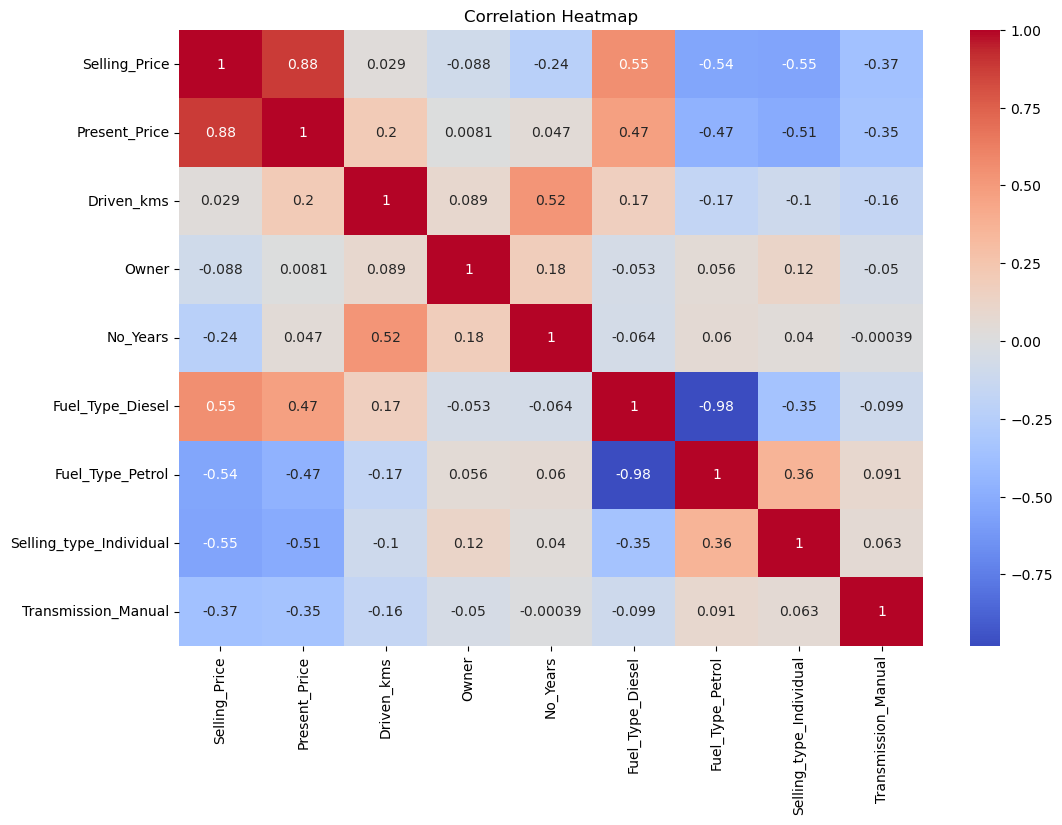

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [9]:
X = df.drop('Selling_Price',axis=1)
y = df['Selling_Price']


In [10]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)


In [11]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
predictions = model.predict(X_test)

In [13]:
print("R2 Score :",r2_score(y_test,predictions))
print("MAE :",mean_absolute_error(y_test,predictions))

R2 Score : 0.9594566919773236
MAE : 0.6368655737704919


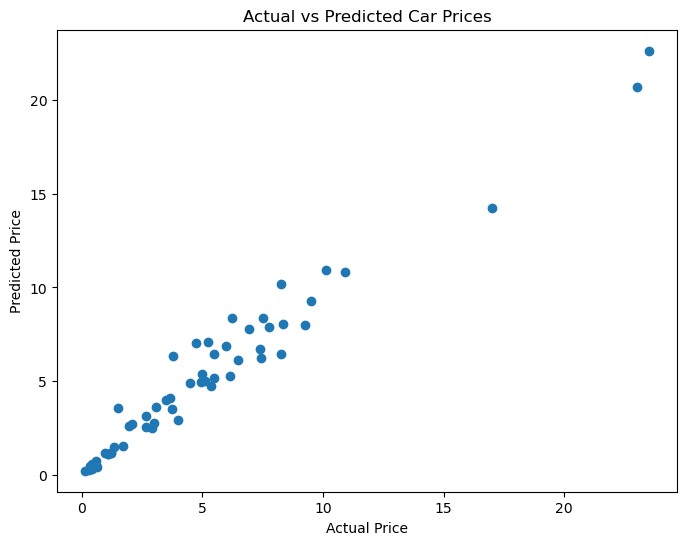

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()


In [15]:
sample = X.iloc[[0]]
price = model.predict(sample)

print("Predicted Price =",price[0],"Lakhs")

Predicted Price = 3.862500000000004 Lakhs
